# Antibiotic resistance from CARD (RGI)

Analysis of the **CARD v4.0.1 / RGI 6.0.8** resistance annotation of the 208,248-plasmid working set.
The confident call set is **Perfect + Strict** (Loose is shown only in the call-quality section, §1, and
never counted elsewhere). Reads the master (`card_*` columns) and the raw hit table
`data/plasmidscope_primary/card_hits.tsv`. Method & validation: `reports/card_amr_methodology.md`.

Sections cover the resistome itself and **plasmid-intrinsic** cross-cuts relevant to ARG spread —
mobility, replicon/Inc type, plasmid size, drug-class co-occurrence, and selected high-priority
determinants. **Habitat cross-cuts are deliberately excluded.** Built by `scripts/build_card_notebook.py`.

**Caveats.** Perfect+Strict is conservative (Loose excluded — see §1); ORF calling linearises circular
sequences so an ARG across the breakpoint may split; SNP/variant model hits (mutational resistance) are
kept separate from acquired homolog hits.

## 0 · Setup

In [1]:
import os, re
from pathlib import Path
from itertools import combinations
from collections import Counter
import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt

while not Path("data/plasmidscope_primary/plasmid_metadata_master.tsv").exists() and Path.cwd() != Path.cwd().parent:
    os.chdir("..")
pd.set_option("display.width", 150)
FIG = Path("reports/figures/card"); FIG.mkdir(parents=True, exist_ok=True)
PP = "data/plasmidscope_primary"

PAL = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
INK, MUTED, GRID = "#1a1a1a", "#6b7280", "#e6e8eb"; GREY, LGREY = "#9aa0a6", "#c9ccd1"
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.labelcolor": INK, "text.color": INK, "axes.edgecolor": "#c9ccd1", "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False})
MOB_ORDER = ["non-mobilizable", "mobilizable", "conjugative"]
MOB_COL = {"non-mobilizable": "#cfe0f5", "mobilizable": "#7cb0e8", "conjugative": "#2a78d6"}
SEQ = "mako_r" if "mako_r" in plt.colormaps() else "viridis"


def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight", facecolor="white")


def hbar_labels(ax, values, fmt="{:,.0f}"):
    vals = list(values); xmax = max(vals) if vals else 1
    for i, v in enumerate(vals):
        ax.text(v + xmax*0.01, i, fmt.format(v), va="center", ha="left", fontsize=9, color=INK)
    ax.set_xlim(0, xmax*1.15)


def multi_count(series, sep=";"):
    c = Counter()
    for s in series:
        for x in str(s).split(sep):
            x = x.strip()
            if x and x != "-":
                c[x] += 1
    return c


def shorten(s, n=26):
    s = s.replace(" antibiotic", "").replace("disinfecting agents and antiseptics", "disinfectant/antiseptic")
    return s if len(s) <= n else s[:n-1] + "…"

In [2]:
M = pd.read_csv(f"{PP}/plasmid_metadata_master.tsv", sep="\t", dtype=str, keep_default_na=False)
n = len(M)
for c in ["card_n_arg", "card_n_arg_unique", "card_n_drug_classes", "card_multidrug", "size_bp"]:
    M[c] = pd.to_numeric(M[c], errors="coerce").fillna(0)
M["card_n_arg"] = M["card_n_arg"].astype(int)
carr = M[M.card_n_arg > 0].copy()                       # AMR+ plasmids (>=1 Perfect/Strict ARG)

H = pd.read_csv(f"{PP}/card_hits.tsv", sep="\t", dtype=str, keep_default_na=False)   # ORF-level, all cut-offs
H["best_identities"] = pd.to_numeric(H["best_identities"], errors="coerce")
HPS = H[H.cut_off.isin(["Perfect", "Strict"])]          # confident ORF hits
n_genes = pd.Series(multi_count(carr.card_aro_list)).size
print(f"working set: {n:,}  |  AMR+ (Perfect/Strict): {len(carr):,} ({100*len(carr)/n:.1f}%)")
print(f"confident ORF hits: {len(HPS):,}  |  distinct ARO genes: {n_genes:,}")
print(f"multidrug (>=2 classes): {int(M.card_multidrug.sum()):,}")

working set: 208,248  |  AMR+ (Perfect/Strict): 29,396 (14.1%)
confident ORF hits: 125,351  |  distinct ARO genes: 1,113
multidrug (>=2 classes): 20,741


### At a glance

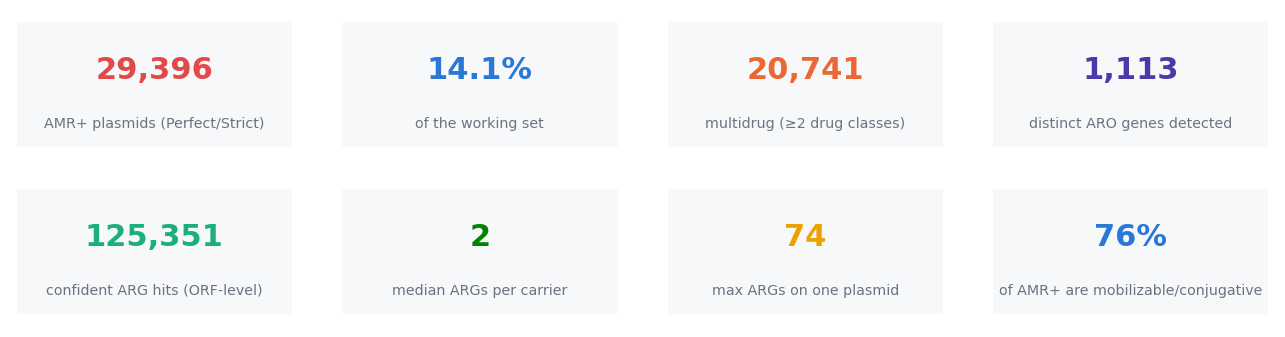

In [3]:
def stat_tiles(items, ncol=4, figsize=(12, 3.2)):
    nrow = int(np.ceil(len(items)/ncol)); fig, ax = plt.subplots(nrow, ncol, figsize=figsize)
    ax = np.atleast_1d(ax).ravel()
    for a, (big, lab, col) in zip(ax, items):
        a.axis("off"); a.add_patch(plt.Rectangle((0.02, 0.08), 0.96, 0.84, transform=a.transAxes, facecolor="#f7f8fa", edgecolor="none"))
        a.text(0.5, 0.60, big, transform=a.transAxes, ha="center", va="center", fontsize=20, fontweight="bold", color=col)
        a.text(0.5, 0.24, lab, transform=a.transAxes, ha="center", va="center", fontsize=9.3, color=MUTED)
    for a in ax[len(items):]:
        a.axis("off")
    fig.tight_layout(); return fig

mob_amr = carr.predicted_mobility.isin(["mobilizable", "conjugative"]).mean()*100
tiles = [
    (f"{len(carr):,}", "AMR+ plasmids (Perfect/Strict)", PAL[5]),
    (f"{100*len(carr)/n:.1f}%", "of the working set", PAL[0]),
    (f"{int(M.card_multidrug.sum()):,}", "multidrug (≥2 drug classes)", PAL[7]),
    (f"{n_genes:,}", "distinct ARO genes detected", PAL[4]),
    (f"{len(HPS):,}", "confident ARG hits (ORF-level)", PAL[1]),
    (f"{int(carr.card_n_arg.median())}", "median ARGs per carrier", PAL[3]),
    (f"{int(carr.card_n_arg.max())}", "max ARGs on one plasmid", PAL[2]),
    (f"{mob_amr:.0f}%", "of AMR+ are mobilizable/conjugative", PAL[0]),
]
fig = stat_tiles(tiles); save(fig, "00_glance"); plt.show()

## 1 · Call quality & confidence tiers

RGI assigns every hit a **Cut_Off**: **Perfect** (identical to a curated reference), **Strict** (above
the curated bitscore), or **Loose** (below it). We keep **Perfect + Strict** everywhere else; this panel
shows why. Loose is 80% of all hits but sits at much lower identity; Perfect/Strict cluster near 100%.
The confident set is dominated by **protein homolog models** (acquired ARGs), with a minority of
overexpression/variant (mutational-resistance) models kept flagged and separate.

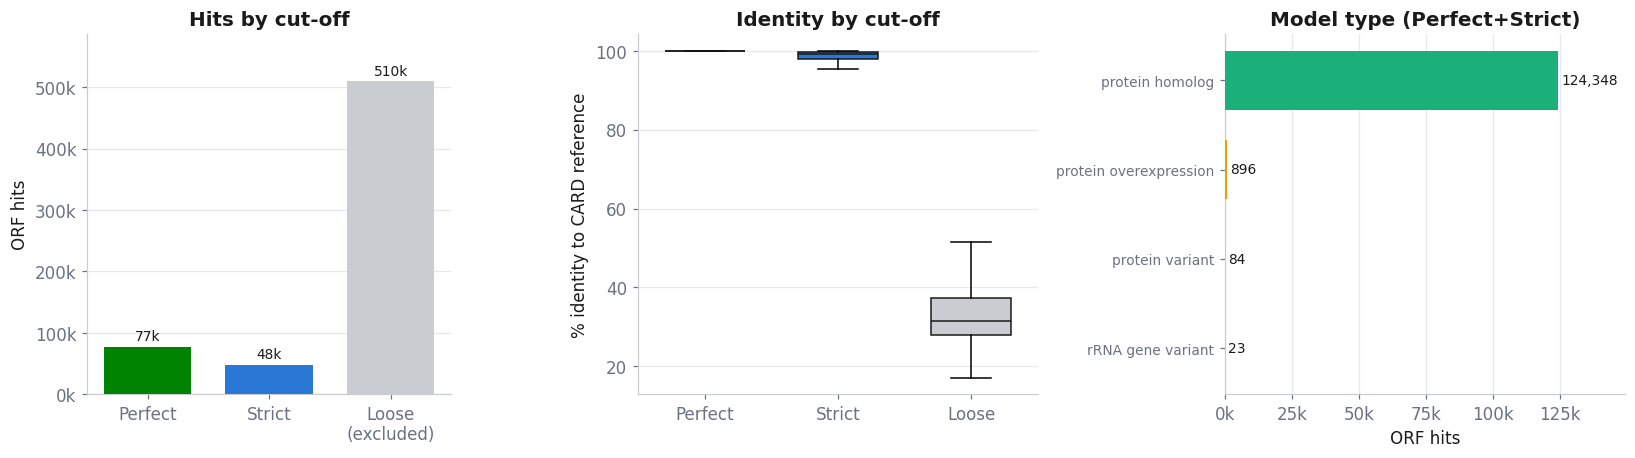

In [4]:
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(15, 4.3), gridspec_kw={"width_ratios": [1, 1.1, 1.1]})

co = H.cut_off.value_counts().reindex(["Perfect", "Strict", "Loose"])
cols = [PAL[3], PAL[0], LGREY]
bars = a1.bar(range(3), co.values, color=cols, width=0.72, zorder=3)
for b, v in zip(bars, co.values):
    a1.text(b.get_x()+b.get_width()/2, v+max(co.values)*0.01, f"{v/1000:.0f}k", ha="center", va="bottom", fontsize=9, color=INK)
a1.set_xticks(range(3)); a1.set_xticklabels(["Perfect", "Strict", "Loose\n(excluded)"])
a1.set_title("Hits by cut-off"); a1.set_ylabel("ORF hits")
a1.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")); a1.set_ylim(0, max(co.values)*1.15); a1.grid(axis="x", visible=False)

data = [H.loc[H.cut_off == c, "best_identities"].dropna() for c in ["Perfect", "Strict", "Loose"]]
bp = a2.boxplot(data, vert=True, patch_artist=True, widths=0.6, showfliers=False)
for patch, col in zip(bp["boxes"], cols):
    patch.set_facecolor(col); patch.set_edgecolor(INK)
for med in bp["medians"]:
    med.set_color(INK)
a2.set_xticklabels(["Perfect", "Strict", "Loose"]); a2.set_ylabel("% identity to CARD reference")
a2.set_title("Identity by cut-off"); a2.grid(axis="x", visible=False)

mt = HPS.model_type.str.replace(" model", "", regex=False).value_counts().sort_values()
a3.barh(range(len(mt)), mt.values, color=[PAL[1] if "homolog" in m else PAL[2] for m in mt.index], height=0.66, zorder=3)
a3.set_yticks(range(len(mt))); a3.set_yticklabels(mt.index, fontsize=9)
for i, v in enumerate(mt.values):
    a3.text(v + max(mt.values)*0.01, i, f"{v:,}", va="center", ha="left", fontsize=9, color=INK)
a3.set_xlim(0, max(mt.values)*1.2); a3.set_title("Model type (Perfect+Strict)"); a3.set_xlabel("ORF hits")
a3.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")); a3.grid(axis="y", visible=False)
fig.tight_layout(); save(fig, "01_call_quality"); plt.show()

## 2 · The resistome — top genes & gene families

Plasmid-level prevalence (number of plasmids carrying each determinant, Perfect+Strict). The leaders are
the canonical **class-1-integron / mobile clinical resistome**: `sul1`+`qacEdelta1` (the 3′-conserved
integron segment), `aadA` aminoglycoside adenylyltransferases, the `TEM-1` β-lactamase, `sul2`, `tet(A)`,
and the `APH`/`AAC` aminoglycoside-modifying enzymes.

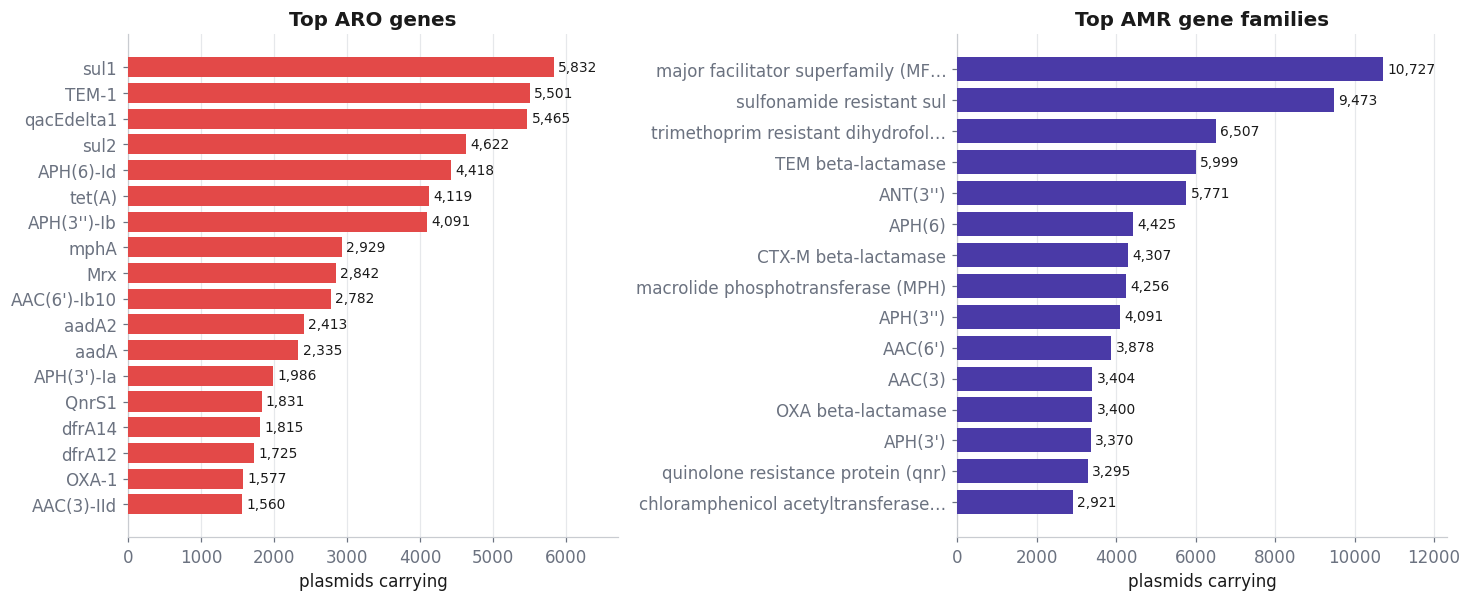

In [5]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 5.6))
genes = pd.Series(multi_count(carr.card_aro_list)).sort_values().tail(18)
a1.barh(genes.index, genes.values, color=PAL[5], height=0.78, zorder=3); hbar_labels(a1, genes.values)
a1.set_title("Top ARO genes"); a1.set_xlabel("plasmids carrying"); a1.grid(axis="y", visible=False)

fam = pd.Series(multi_count(carr.card_amr_gene_families)).sort_values().tail(15)
fam.index = [shorten(x, 34) for x in fam.index]
a2.barh(fam.index, fam.values, color=PAL[4], height=0.78, zorder=3); hbar_labels(a2, fam.values)
a2.set_title("Top AMR gene families"); a2.set_xlabel("plasmids carrying"); a2.grid(axis="y", visible=False)
fig.tight_layout(); save(fig, "02_resistome"); plt.show()

## 3 · Drug classes & multidrug carriage

Which antibiotic classes are threatened, and how many *distinct* classes a resistant plasmid carries.
**70.6% of AMR+ plasmids are multidrug** (≥2 classes) — resistance travels in blocks, not as single genes.

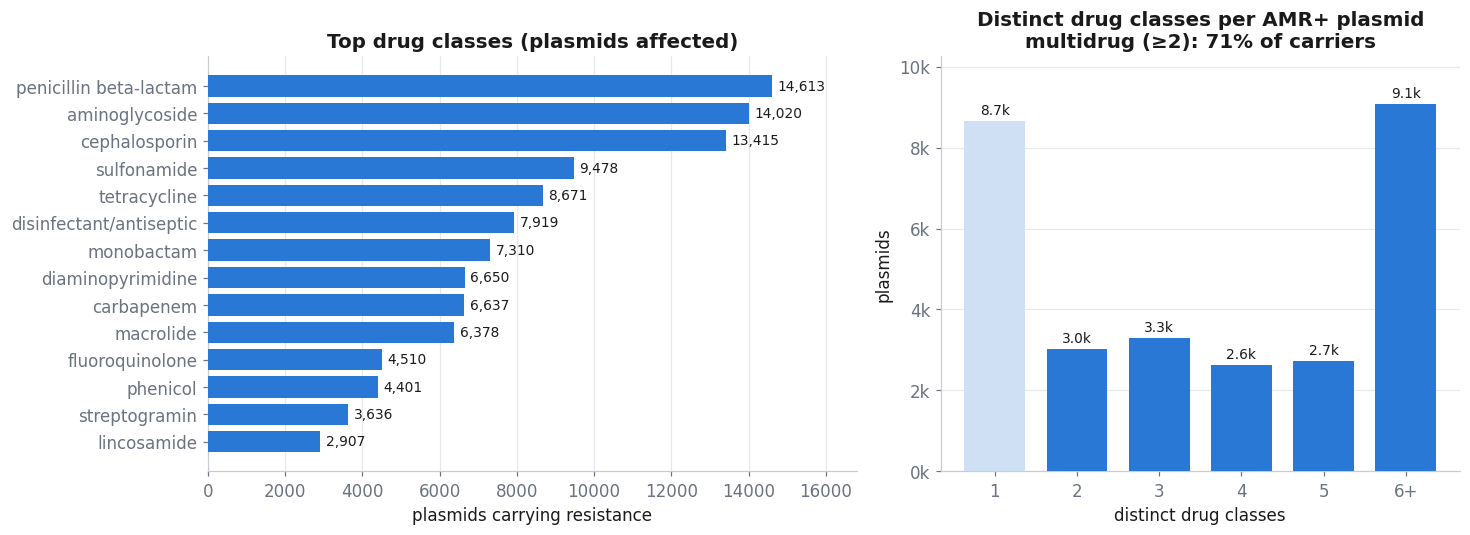

In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 5), gridspec_kw={"width_ratios": [1.25, 1]})
dc = pd.Series(multi_count(carr.card_drug_classes)).sort_values().tail(14)
dc.index = [shorten(x, 30) for x in dc.index]
a1.barh(dc.index, dc.values, color=PAL[0], height=0.78, zorder=3); hbar_labels(a1, dc.values)
a1.set_title("Top drug classes (plasmids affected)"); a1.set_xlabel("plasmids carrying resistance"); a1.grid(axis="y", visible=False)

nd = carr.card_n_drug_classes.clip(upper=6).astype(int).value_counts().sort_index()
lab = {1: "1", 2: "2", 3: "3", 4: "4", 5: "5", 6: "6+"}
mdr = (carr.card_n_drug_classes >= 2).mean()*100
bars = a2.bar([lab[k] for k in nd.index], nd.values,
              color=["#cfe0f5" if k == 1 else PAL[0] for k in nd.index], width=0.74, zorder=3)
for b, v in zip(bars, nd.values):
    a2.text(b.get_x()+b.get_width()/2, v+max(nd.values)*0.01, f"{v/1000:.1f}k", ha="center", va="bottom", fontsize=9, color=INK)
a2.set_title(f"Distinct drug classes per AMR+ plasmid\nmultidrug (≥2): {mdr:.0f}% of carriers")
a2.set_xlabel("distinct drug classes"); a2.set_ylabel("plasmids")
a2.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")); a2.set_ylim(0, max(nd.values)*1.13); a2.grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "03_drug_classes"); plt.show()

## 4 · Resistance mechanisms & burden

The molecular strategy behind the resistome, and how heavily loaded resistant plasmids are. Enzymatic
**antibiotic inactivation** (β-lactamases, aminoglycoside modifiers) leads, followed by **efflux**.
Most carriers hold 1–2 ARGs, but a long tail stacks many determinants on one replicon.

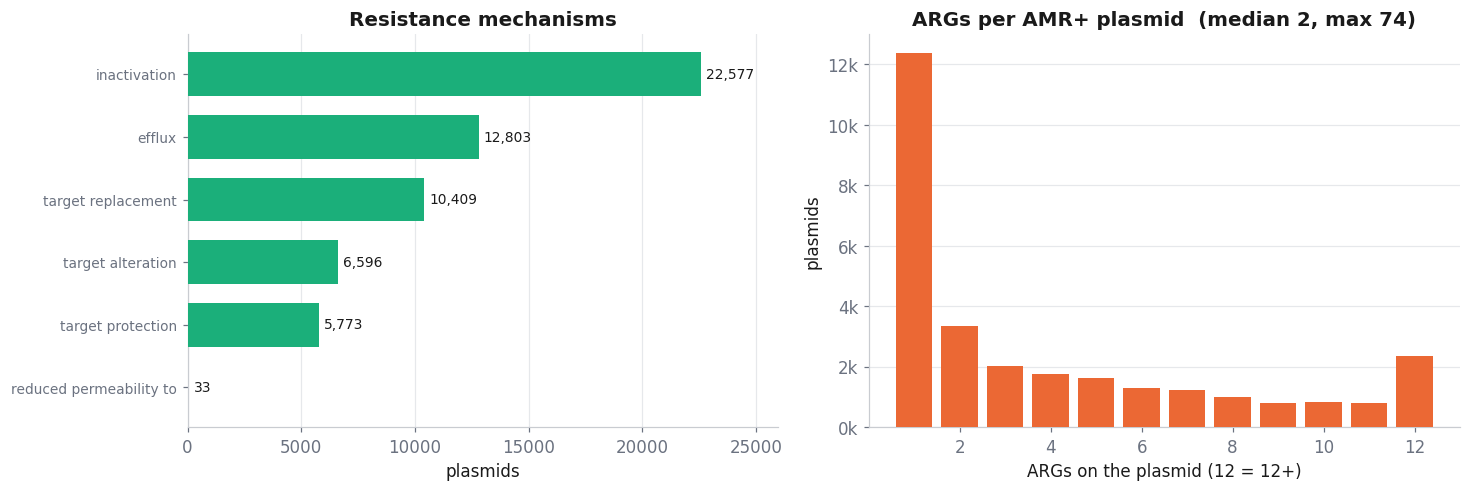

In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 4.6))
mech = pd.Series(multi_count(carr.card_resistance_mechanisms)).sort_values()
mech.index = [shorten(x.replace("antibiotic ", ""), 26) for x in mech.index]
a1.barh(range(len(mech)), mech.values, color=PAL[1], height=0.7, zorder=3)
a1.set_yticks(range(len(mech))); a1.set_yticklabels(mech.index, fontsize=9); hbar_labels(a1, mech.values)
a1.set_title("Resistance mechanisms"); a1.set_xlabel("plasmids"); a1.grid(axis="y", visible=False)

b = carr.card_n_arg.clip(upper=12)
vc = b.value_counts().sort_index()
bars = a2.bar(vc.index, vc.values, color=PAL[7], width=0.8, zorder=3)
a2.set_title(f"ARGs per AMR+ plasmid  (median {int(carr.card_n_arg.median())}, max {int(carr.card_n_arg.max())})")
a2.set_xlabel("ARGs on the plasmid (12 = 12+)"); a2.set_ylabel("plasmids")
a2.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")); a2.grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "04_mechanisms_burden"); plt.show()

## 5 · Resistance vs plasmid size

Do resistant — and multi-resistant — plasmids run larger? Grouping by ARG count (0 = AMR−) shows the size
distribution climb: heavily-loaded resistance plasmids are markedly larger, consistent with resistance
accreting onto larger, often-conjugative backbones.

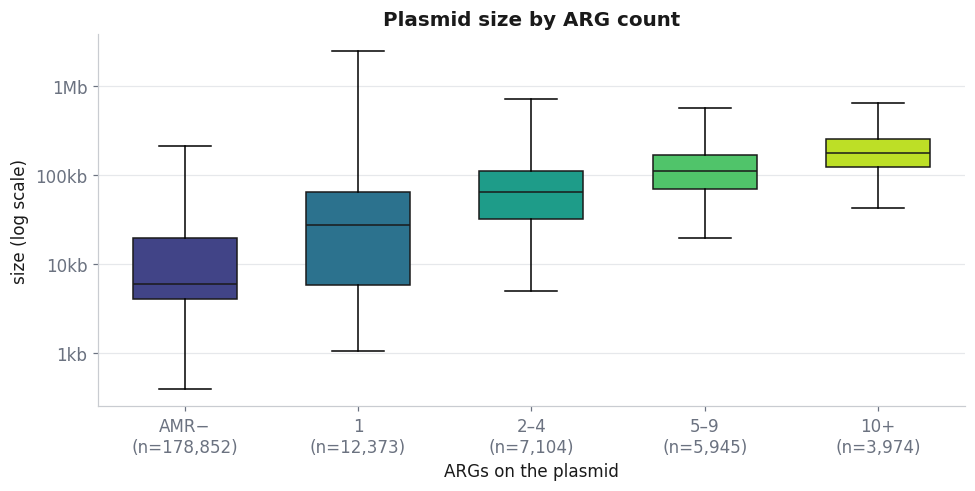

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.6))
bins = [(0, 0, "AMR−"), (1, 1, "1"), (2, 4, "2–4"), (5, 9, "5–9"), (10, 999, "10+")]
data, labs = [], []
for lo, hi, lab in bins:
    s = M.loc[(M.card_n_arg >= lo) & (M.card_n_arg <= hi) & (M.size_bp > 0), "size_bp"]
    data.append(np.log10(s.dropna())); labs.append(f"{lab}\n(n={len(s):,})")
ramp = plt.get_cmap(SEQ)(np.linspace(0.2, 0.9, len(bins)))
bp = ax.boxplot(data, vert=True, patch_artist=True, widths=0.6, showfliers=False)
for patch, c in zip(bp["boxes"], ramp):
    patch.set_facecolor(c); patch.set_edgecolor(INK)
for med in bp["medians"]:
    med.set_color(INK)
ax.set_xticklabels(labs); ax.set_yticks([3, 4, 5, 6]); ax.set_yticklabels(["1kb", "10kb", "100kb", "1Mb"])
ax.set_title("Plasmid size by ARG count"); ax.set_ylabel("size (log scale)"); ax.set_xlabel("ARGs on the plasmid")
ax.grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "05_size_by_burden"); plt.show()

## 6 · Resistance vs mobility

The ARG-spread question: is resistance carried on **mobile** plasmids? AMR prevalence rises sharply with
mobility — conjugative plasmids (self-transmissible) are the most likely to be resistant and the most
likely to be multidrug — so the resistome is concentrated on exactly the plasmids that can move it
between cells. (Mobility = MOB-suite `predicted_mobility`; not a habitat variable.)

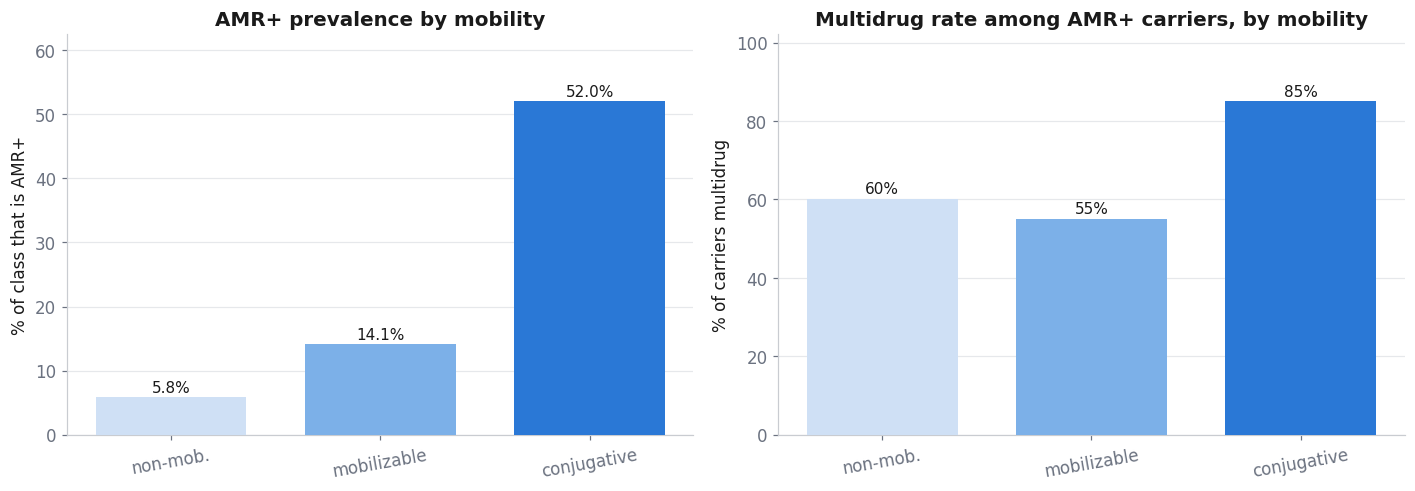

In [9]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
amr_rate = M.groupby("predicted_mobility").apply(lambda g: (g.card_n_arg > 0).mean()*100).reindex(MOB_ORDER)
bars = a1.bar(range(3), amr_rate.values, color=[MOB_COL[m] for m in MOB_ORDER], width=0.72, zorder=3)
for b, v in zip(bars, amr_rate.values):
    a1.text(b.get_x()+b.get_width()/2, v+0.3, f"{v:.1f}%", ha="center", va="bottom", fontsize=10, color=INK)
a1.set_xticks(range(3)); a1.set_xticklabels(["non-mob.", "mobilizable", "conjugative"], rotation=10)
a1.set_title("AMR+ prevalence by mobility"); a1.set_ylabel("% of class that is AMR+")
a1.set_ylim(0, amr_rate.max()*1.2); a1.grid(axis="x", visible=False)

mdr_rate = carr.groupby("predicted_mobility").apply(lambda g: (g.card_n_drug_classes >= 2).mean()*100).reindex(MOB_ORDER)
bars = a2.bar(range(3), mdr_rate.values, color=[MOB_COL[m] for m in MOB_ORDER], width=0.72, zorder=3)
for b, v in zip(bars, mdr_rate.values):
    a2.text(b.get_x()+b.get_width()/2, v+0.6, f"{v:.0f}%", ha="center", va="bottom", fontsize=10, color=INK)
a2.set_xticks(range(3)); a2.set_xticklabels(["non-mob.", "mobilizable", "conjugative"], rotation=10)
a2.set_title("Multidrug rate among AMR+ carriers, by mobility"); a2.set_ylabel("% of carriers multidrug")
a2.set_ylim(0, max(mdr_rate.values)*1.2); a2.grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "06_amr_by_mobility"); plt.show()

## 7 · Resistance vs replicon (Inc) type

Which replicon families carry the resistome (PlasmidFinder ≥80/60 Inc families). The IncF complex and the
small mobilizable `Col` replicons dominate AMR carriage — the classic vehicles of Enterobacterales
resistance. Bars are AMR+ plasmid counts; the % is the AMR+ rate *within* that Inc family.

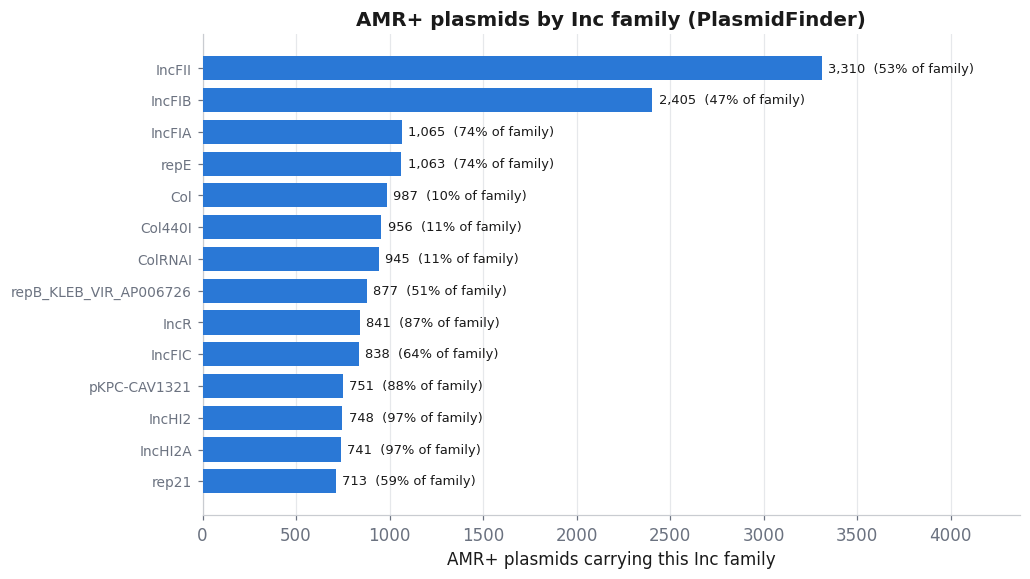

In [10]:
fig, ax = plt.subplots(figsize=(9.5, 5.4))
amr_fam = pd.Series(multi_count(carr.pf_inc_families))
all_fam = pd.Series(multi_count(M.pf_inc_families))
top = amr_fam.sort_values().tail(14)
rate = (top / all_fam.reindex(top.index) * 100)
ax.barh(range(len(top)), top.values, color=PAL[0], height=0.76, zorder=3)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=9)
xmax = top.max()
for i, (v, r) in enumerate(zip(top.values, rate.values)):
    ax.text(v + xmax*0.01, i, f"{v:,}  ({r:.0f}% of family)", va="center", ha="left", fontsize=8.5, color=INK)
ax.set_xlim(0, xmax*1.32); ax.set_title("AMR+ plasmids by Inc family (PlasmidFinder)")
ax.set_xlabel("AMR+ plasmids carrying this Inc family"); ax.grid(axis="y", visible=False)
fig.tight_layout(); save(fig, "07_amr_by_inc"); plt.show()

## 8 · Drug-class co-occurrence

How resistance classes travel together on the same plasmid. The diagonal is each class's plasmid count;
off-diagonal cells count plasmids carrying **both** classes. The dense β-lactam / aminoglycoside /
sulfonamide / tetracycline block is the co-selected multidrug cassette that class-1 integrons assemble.

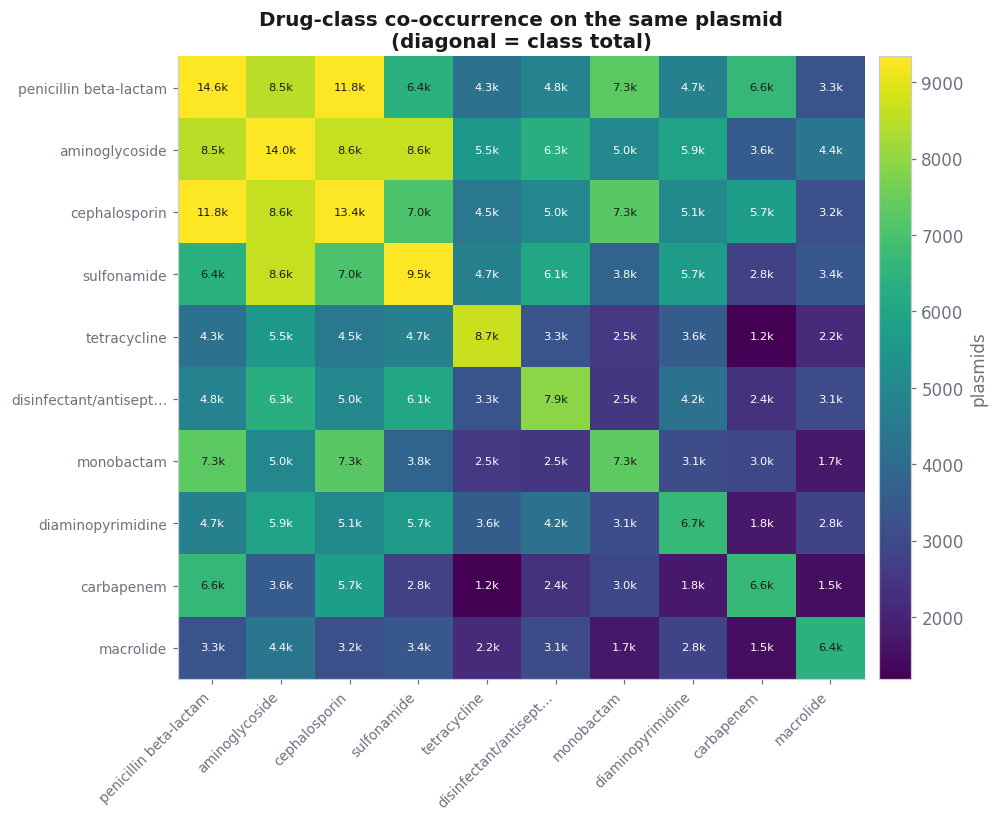

In [11]:
top_classes = [c for c, _ in pd.Series(multi_count(carr.card_drug_classes)).sort_values(ascending=False).head(10).items()]
idx = {c: i for i, c in enumerate(top_classes)}
k = len(top_classes); co = np.zeros((k, k))
for cell in carr.card_drug_classes:
    present = [c.strip() for c in str(cell).split(";") if c.strip() in idx]
    for c in present:
        co[idx[c], idx[c]] += 1
    for a, b in combinations(sorted(set(present)), 2):
        co[idx[a], idx[b]] += 1; co[idx[b], idx[a]] += 1

fig, ax = plt.subplots(figsize=(9.2, 7.6))
off = co.copy(); np.fill_diagonal(off, 0)
vmax = np.percentile(off[off > 0], 98)
im = ax.imshow(co, cmap=SEQ, aspect="auto", vmax=vmax)
cmap = plt.get_cmap(SEQ)
labs = [shorten(c, 22) for c in top_classes]
ax.set_xticks(range(k)); ax.set_xticklabels(labs, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(k)); ax.set_yticklabels(labs, fontsize=9)
for i in range(k):
    for j in range(k):
        v = int(co[i, j])
        if v:
            r, g, b = cmap(min(co[i, j]/vmax, 1.0))[:3]      # ink/white by actual cell luminance
            tc = "white" if (0.299*r + 0.587*g + 0.114*b) < 0.55 else INK
            ax.text(j, i, f"{v/1000:.1f}k" if v >= 1000 else f"{v}", ha="center", va="center", fontsize=7.5, color=tc)
ax.set_title("Drug-class co-occurrence on the same plasmid\n(diagonal = class total)"); ax.grid(False)
fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046).set_label("plasmids", color=MUTED)
fig.tight_layout(); save(fig, "08_cooccurrence"); plt.show()

## 9 · Selected high-priority determinants

Plasmids carrying clinically critical resistance, pattern-matched on the CARD gene name among
Perfect+Strict calls. These are the mobile determinants of greatest public-health concern — extended-
spectrum and carbapenem β-lactamases, plasmid-borne colistin (`mcr`), vancomycin (`van`) and methicillin
(`mecA`) resistance. Counts are conservative (curated name patterns; carbapenemase restricted to the
named enzymes, not all `OXA`).

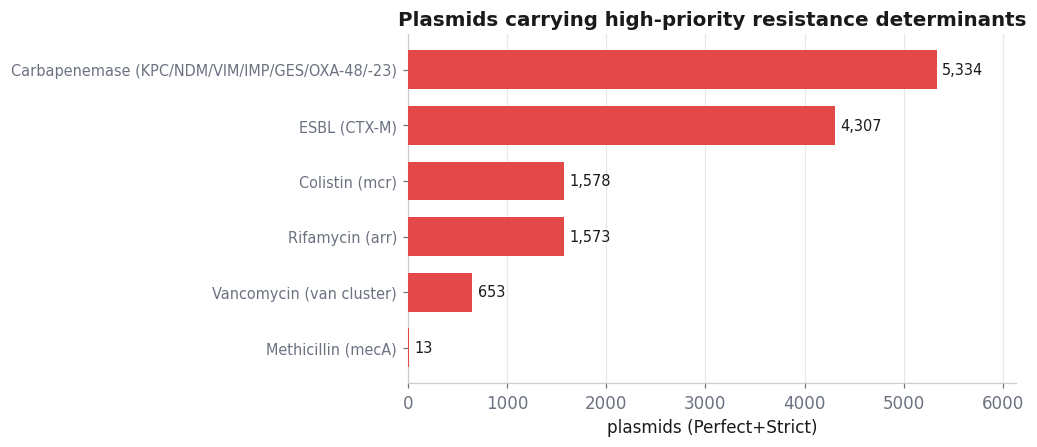

In [12]:
CRIT = {
    "ESBL (CTX-M)": r"CTX-M",
    "Carbapenemase (KPC/NDM/VIM/IMP/GES/OXA-48/-23)": r"\b(KPC|NDM|VIM|IMP-\d|GES-\d|SPM|GIM|OXA-48|OXA-23|OXA-181)\b",
    "Colistin (mcr)": r"MCR-\d|\bmcr-\d",
    "Vancomycin (van cluster)": r"\bVan[A-Z]\b|\bvan[A-Z]\b",
    "Methicillin (mecA)": r"\bmecA\b",
    "Rifamycin (arr)": r"\barr-\d",
}
rows = []
for lab, pat in CRIT.items():
    rgx = re.compile(pat, re.IGNORECASE)
    cnt = carr.card_aro_list.apply(lambda s: bool(rgx.search(str(s)))).sum()
    rows.append((lab, int(cnt)))
rows.sort(key=lambda x: x[1])
fig, ax = plt.subplots(figsize=(9.5, 4.2))
labs = [r[0] for r in rows]; vals = [r[1] for r in rows]
ax.barh(range(len(rows)), vals, color=PAL[5], height=0.7, zorder=3)
ax.set_yticks(range(len(rows))); ax.set_yticklabels(labs, fontsize=9.5)
xmax = max(vals) if vals else 1
for i, v in enumerate(vals):
    ax.text(v + xmax*0.01, i, f"{v:,}", va="center", ha="left", fontsize=9.5, color=INK)
ax.set_xlim(0, xmax*1.15); ax.set_title("Plasmids carrying high-priority resistance determinants")
ax.set_xlabel("plasmids (Perfect+Strict)"); ax.grid(axis="y", visible=False)
fig.tight_layout(); save(fig, "09_critical"); plt.show()

## 10 · Summary & data dictionary

**Headline findings (CARD v4.0.1, Perfect+Strict)**

- **29,396 plasmids (14.1%) are AMR+**; **20,741 (70.6% of carriers) are multidrug** (≥2 drug classes).
  Median 2 ARGs per carrier, maximum 74.
- **Resistome** led by the class-1-integron / mobile clinical resistome: `sul1`, `TEM-1`, `qacEdelta1`,
  `sul2`, `APH(6)-Id`, `tet(A)`, `APH(3'')-Ib`, `aadA`.
- **Drug classes** most affected: β-lactams (penicillin/cephalosporin/monobactam/carbapenem),
  aminoglycoside, sulfonamide, tetracycline; **mechanism** dominated by enzymatic inactivation then efflux.
- **Resistance is concentrated on mobile plasmids** — AMR+ prevalence and multidrug rate both rise
  from non-mobilizable → mobilizable → conjugative.
- **Larger plasmids carry more ARGs**; the heavily-loaded tail sits on large, often-conjugative backbones.
- **Inc carriage** dominated by the IncF complex and `Col` replicons.
- **High-priority determinants** (CTX-M ESBLs, carbapenemases, `mcr`, `van`, `mecA`) are quantified in §9.

**Validation.** 90.5% presence/absence concordance with PLSDB's independent AMRFinderPlus calls; the
disagreement is 93%-explained by CARD Loose hits we exclude (→ ~99.4% if Loose counted). See
`reports/card_amr_methodology.md`.

**CARD columns in the master**

| column | meaning |
|---|---|
| `card_n_arg` / `card_n_arg_unique` | Perfect+Strict ARG hits / distinct ARO genes |
| `card_aro_list` | `;`-joined ARO gene names |
| `card_drug_classes` / `card_n_drug_classes` | affected drug classes / their count |
| `card_resistance_mechanisms` | resistance mechanisms |
| `card_amr_gene_families` | AMR gene families |
| `card_multidrug` | 1 if ≥2 distinct drug classes |

*Generated by `scripts/build_card_notebook.py`; annotation by `scripts/card_array.sbatch` +
`scripts/card_task.sh`, harvested/aggregated by `scripts/harvest_card.py` + `scripts/aggregate_card.py`,
folded by `scripts/build_metadata_master.py`. Raw hits: `data/plasmidscope_primary/card_hits.tsv`.
Method: `reports/card_amr_methodology.md`. Figures in `reports/figures/card/`. Habitat cross-cuts
intentionally excluded.*